import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import time
import os
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

load prepossed data

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

test_df = pd.read_csv(
    "../data/processed/test_processed.csv"
)

In [3]:
print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (453204, 31)
Testing Shape: (56746, 31)


separate X and Y

In [4]:
X_train = train_df.drop(
    columns=["Class"]
)

y_train = train_df["Class"]

In [5]:
X_test = test_df.drop(
    columns=["Class"]
)

y_test = test_df["Class"]

In [6]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (453204, 30)
y_train: (453204,)
X_test: (56746, 30)
y_test: (56746,)


Verify Class Distribution

In [7]:
print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
Class
0    226602
1    226602
Name: count, dtype: int64

Testing:
Class
0    56651
1       95
Name: count, dtype: int64


Create Results Storage

In [8]:
results = []

Logistic Regression

In [9]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [10]:
start_time = time.perf_counter()

logistic_model.fit(
    X_train,
    y_train
)

logistic_training_time = (
    time.perf_counter() - start_time
)

In [11]:
logistic_predictions = logistic_model.predict(
    X_test
)

In [12]:
logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]

In [13]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1 Score": logistic_f1,
    "ROC-AUC": logistic_roc_auc,
    "Training Time (sec)": logistic_training_time
}

results.append(logistic_results)


Decision Tree

In [14]:
decision_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

In [15]:
start_time = time.perf_counter()

decision_tree.fit(
    X_train,
    y_train
)

decision_tree_training_time = (
    time.perf_counter() - start_time
)

In [16]:
decision_tree_predictions = decision_tree.predict(
    X_test
)

In [17]:
decision_tree_probabilities = decision_tree.predict_proba(
    X_test
)[:, 1]

In [18]:
decision_tree_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(
        y_test,
        decision_tree_predictions
    ),
    "Precision": precision_score(
        y_test,
        decision_tree_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        decision_tree_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        decision_tree_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        decision_tree_probabilities
    ),
    "Training Time (sec)": decision_tree_training_time
}

results.append(decision_tree_results)

Random Forest

In [19]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

In [20]:
start_time = time.perf_counter()

random_forest.fit(
    X_train,
    y_train
)

random_forest_training_time = (
    time.perf_counter() - start_time
)

In [21]:
random_forest_predictions = random_forest.predict(
    X_test
)

In [22]:
random_forest_probabilities = random_forest.predict_proba(
    X_test
)[:, 1]


In [23]:
random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(
        y_test,
        random_forest_predictions
    ),
    "Precision": precision_score(
        y_test,
        random_forest_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        random_forest_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        random_forest_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        random_forest_probabilities
    ),
    "Training Time (sec)": random_forest_training_time
}

results.append(random_forest_results)

KNN algorithm

In [24]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

In [25]:
start_time = time.perf_counter()

knn_model.fit(
    X_train,
    y_train
)

knn_training_time = (
    time.perf_counter() - start_time
)

In [26]:
knn_predictions = knn_model.predict(
    X_test
)

In [27]:
knn_probabilities = knn_model.predict_proba(
    X_test
)[:, 1]

In [28]:
knn_results = {
    "Model": "KNN",
    "Accuracy": accuracy_score(
        y_test,
        knn_predictions
    ),
    "Precision": precision_score(
        y_test,
        knn_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        knn_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        knn_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        knn_probabilities
    ),
    "Training Time (sec)": knn_training_time
}

results.append(knn_results)

Model Comparison Table

In [29]:
results_df = pd.DataFrame(
    results
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.962618,1.748681
1,Decision Tree,0.985567,0.082949,0.757895,0.149533,0.816300,29.078407
2,Random Forest,0.998996,0.672727,0.778947,0.721951,0.980577,42.162550
3,KNN,0.997973,0.442529,0.810526,0.572491,0.909967,0.109279


In [30]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Logistic Regression,0.9737,0.0530,0.8737,0.1000,0.9626,1.7487
1,Decision Tree,0.9856,0.0829,0.7579,0.1495,0.8163,29.0784
2,Random Forest,0.9990,0.6727,0.7789,0.7220,0.9806,42.1625
3,KNN,0.9980,0.4425,0.8105,0.5725,0.9100,0.1093


find the best model

In [31]:
best_f1_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Model Based on F1 Score:")
print(best_f1_model)

Best Model Based on F1 Score:
Model                  Random Forest
Accuracy                    0.998996
Precision                   0.672727
Recall                      0.778947
F1 Score                    0.721951
ROC-AUC                     0.980577
Training Time (sec)         42.16255
Name: 2, dtype: object


Confusion Matrix - Random Forest

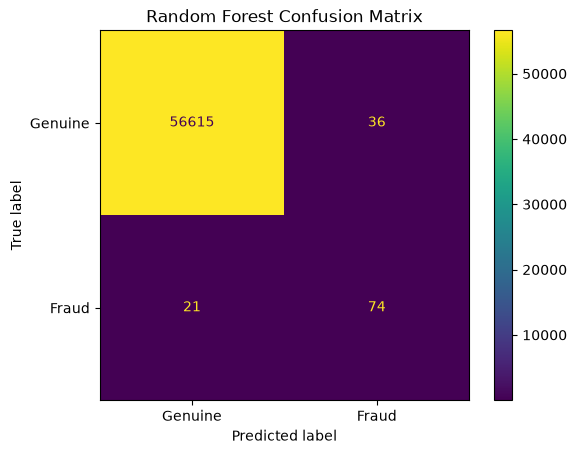

In [32]:
cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Genuine",
        "Fraud"
    ]
)

disp.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

Random Forest Feature Importance

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)


In [34]:
feature_importance.head(15)

,Feature,Importance
0,V14,0.201709
1,V10,0.119472
2,V12,0.100384
3,V17,0.094342
4,V4,0.088219
5,V3,0.059485
6,V11,0.059483
7,V16,0.058173
8,V2,0.038246
9,V9,0.025082


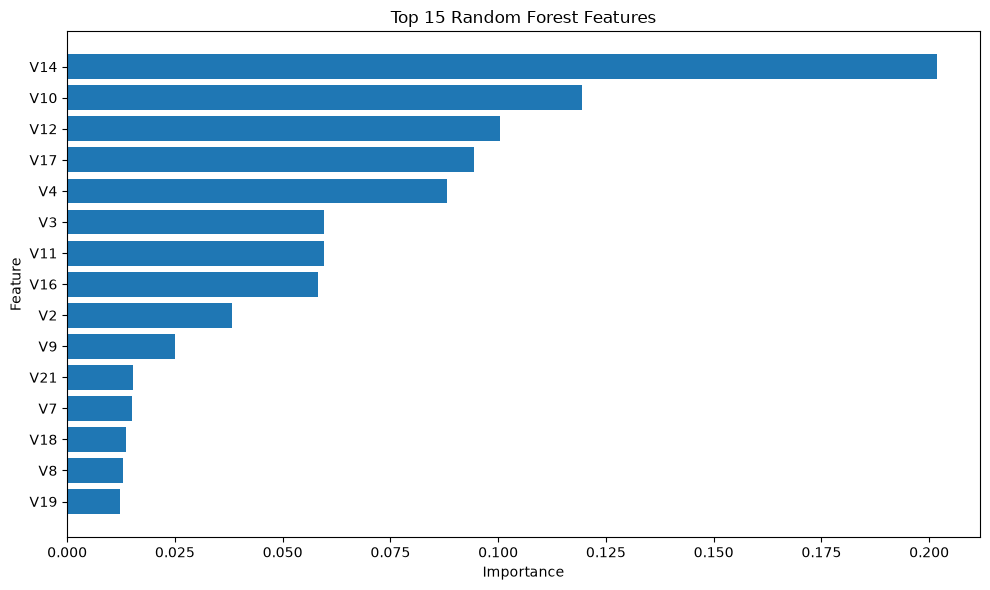

In [35]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Random Forest Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Compare Metrics Visually

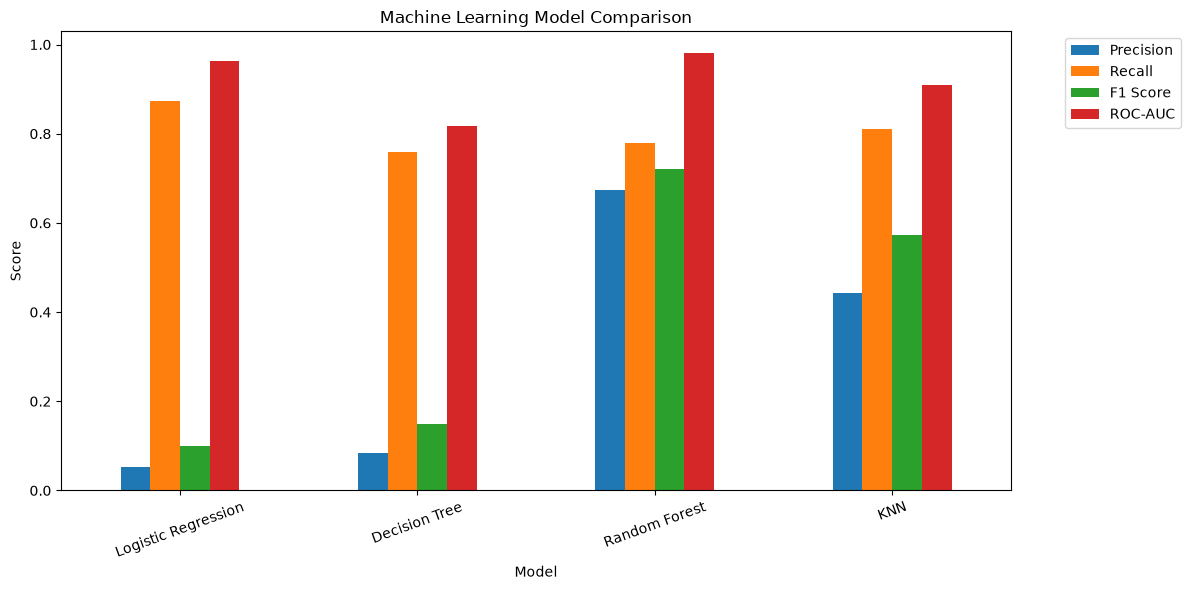

In [36]:
metrics = [
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_plot = results_df.set_index(
    "Model"
)[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Machine Learning Model Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=20)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Save the comparison table

In [37]:
os.makedirs(
    "../outputs/metrics",
    exist_ok=True
)

results_df.to_csv(
    "../outputs/metrics/ml_model_comparison.csv",
    index=False
)

save the random forest model

In [38]:
os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    random_forest,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']


save logistic regression model

In [39]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

['../models/logistic_regression.pkl']


verify models

In [40]:
print("Models saved successfully!")

print(
    os.listdir("../models")
)

Models saved successfully!
['logistic_regression.pkl', 'random_forest.pkl', 'scaler.pkl']
